<a href="https://colab.research.google.com/github/JaiShankar14/Jaishankar-Ganesan.github.io/blob/main/Autonomus_Rover_YOLO_Model(Severity_Category).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q ultralytics kaggle opencv-python tqdm pyyaml

In [ ]:
!pip install -q kagglehub
!pip install -q opencv-python tqdm

In [ ]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:14<00:00, 195MB/s]



In [ ]:
!unzip -q new-plant-diseases-dataset.zip -d /content/

In [ ]:
import os

SOURCE = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

print(os.listdir(SOURCE))

['train', 'valid']


In [ ]:
import os

OUTPUT = "/content/PlantYOLO"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(OUTPUT, folder), exist_ok=True)

print("Folders created.")

Folders created.


In [ ]:
train_dir = os.path.join(SOURCE, "train")

classes = sorted(os.listdir(train_dir))

class_to_id = {
    name: idx
    for idx, name in enumerate(classes)
}

print("Total Classes:", len(classes))

print(classes[:10])

Total Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


In [ ]:
import shutil
from glob import glob
from tqdm import tqdm

def convert(split_input, split_output):

    source_folder = os.path.join(SOURCE, split_input)

    image_output = os.path.join(OUTPUT, "images", split_output)

    label_output = os.path.join(OUTPUT, "labels", split_output)

    for cls in tqdm(classes):

        cls_id = class_to_id[cls]

        images = []

        for ext in ["*.jpg","*.JPG","*.jpeg","*.JPEG","*.png"]:
            images.extend(glob(os.path.join(source_folder, cls, ext)))

        for img in images:

            filename = os.path.basename(img)

            shutil.copy(img, os.path.join(image_output, filename))

            label_name = os.path.splitext(filename)[0] + ".txt"

            with open(os.path.join(label_output, label_name), "w") as f:
                f.write(f"{cls_id} 0.5 0.5 1.0 1.0")

In [ ]:
convert("train", "train")
convert("valid", "val")

print("Conversion Finished")

100%|██████████| 38/38 [00:04<00:00,  8.56it/s]

Conversion Finished


In [ ]:
import yaml

data = {
    "path": OUTPUT,
    "train": "images/train",
    "val": "images/val",
    "nc": len(classes),
    "names": classes
}

with open("/content/plant.yaml","w") as f:
    yaml.dump(data, f)

print(data)

{'path': '/content/PlantYOLO', 'train': 'images/train', 'val': 'images/val', 'nc': 38, 'names': ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'To

In [ ]:
print(os.listdir("/content/PlantYOLO/images/train")[:5])

print(os.listdir("/content/PlantYOLO/labels/train")[:5])

['413bc2e9-eb2a-48fd-ba65-48b5121fd85c___RS_HL 4200.JPG', 'RS_Rust 1850_flipLR.JPG', '5786dc07-0a0f-460b-896b-2bb4a240679e___RS_GLSp 7282.JPG', 'd7f1e802-0b8e-4cba-88b4-e61328322cac___RS_Erly.B 8222.JPG', '41dc26ff-7912-4bda-9ff5-e138dd3c7131___Rut._Bact.S 3491.JPG']
['ca6362b2-b680-4348-a795-3bc37275e70f___GHLB2 Leaf 79.txt', 'ea9d49e5-e3ee-4429-8592-4ce9a910376f___NREC_B.Spot 1821_180deg.txt', 'e0e7eca2-7bfa-40c8-b622-9fcdbdb43369___CREC_HLB 7783.txt', '143e8197-a7d6-48a7-8e9e-05cd7dd1323f___FAM_B.Rot 0421_flipLR.txt', '6d4ccc3a-c410-4d67-8858-e411ad1c4486___FREC_Pwd.M 5007_flipLR.txt']


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("/content/best (6).pt")

In [ ]:
import glob

# Change this to your dataset location

images = glob.glob("/content/**/*.jpg", recursive=True)

print("Number of images:", len(images))

print("First image:", images[0])

Number of images: 9138
First image: /content/PlantYOLO/images/train/59d8a372-0690-4767-9795-ea96ac386393___R.S_HL 0596 copy 2.jpg


In [ ]:
import cv2

image_path = images[0]      # or choose any image
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(image_path)

original = image.copy()
print("Loaded:", image_path)

Loaded: /content/PlantYOLO/images/train/59d8a372-0690-4767-9795-ea96ac386393___R.S_HL 0596 copy 2.jpg


In [ ]:
results = model(image)

result = results[0]


0: 640x640 1 Corn_(maize)___healthy, 8.9ms
Speed: 13.3ms preprocess, 8.9ms inference, 39.7ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
def calculate_severity(leaf_roi):

    hsv = cv2.cvtColor(leaf_roi, cv2.COLOR_BGR2HSV)

    # Green leaf mask
    lower_green = np.array([25,40,40])
    upper_green = np.array([95,255,255])

    leaf_mask = cv2.inRange(hsv, lower_green, upper_green)

    leaf_area = cv2.countNonZero(leaf_mask)

    # Brown/Yellow disease mask

    lower_disease = np.array([5,40,40])
    upper_disease = np.array([35,255,255])

    disease_mask = cv2.inRange(hsv,
                               lower_disease,
                               upper_disease)

    disease_area = cv2.countNonZero(disease_mask)

    if leaf_area == 0:
        return 0

    severity = (disease_area / leaf_area) * 100

    return severity

In [ ]:
def severity_level(value):

    if value == 0:
        return "Healthy"

    elif value <=20:
        return "Low"

    elif value<=50:
        return "Moderate"

    elif value<=75:
        return "High"

    else:
        return "Critical"

In [ ]:
for box in result.boxes:

    cls = int(box.cls)

    disease_name = model.names[cls]

    confidence = float(box.conf)

    x1,y1,x2,y2 = map(int,box.xyxy[0])

    roi = image[y1:y2,x1:x2]

    severity = calculate_severity(roi)

    level = severity_level(severity)

    cv2.rectangle(original,
                  (x1,y1),
                  (x2,y2),
                  (0,255,0),
                  2)

    text = f"{disease_name} {confidence:.2f}"

    text2 = f"{severity:.1f}% ({level})"

    cv2.putText(original,
                text,
                (x1,y1-30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255,0,0),
                2)

    cv2.putText(original,
                text2,
                (x1,y1-8),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,0,255),
                2)

    print("------------------------------------")
    print("Disease :", disease_name)
    print("Confidence :", confidence)
    print("Severity :", round(severity,2),"%")
    print("Level :", level)

------------------------------------
Disease : Corn_(maize)___healthy
Confidence : 0.9946840405464172
Severity : 0.01 %
Level : Low


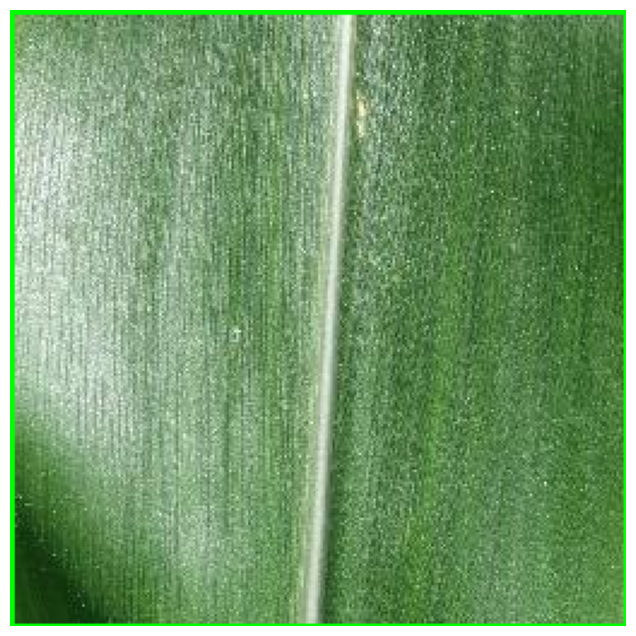

In [ ]:
plt.figure(figsize=(12,8))

plt.imshow(cv2.cvtColor(original,
                        cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()

**Severity For all validation**

In [ ]:
import os
import glob
import cv2
import numpy as np
from ultralytics import YOLO

model = YOLO("/content/best (6).pt")

VALID_FOLDER = "/content/PlantYOLO/images/val"

SAVE_FOLDER = "/content/Severity_Output"

os.makedirs(SAVE_FOLDER, exist_ok=True)

images = glob.glob(os.path.join(VALID_FOLDER, "*.jpg"))
images += glob.glob(os.path.join(VALID_FOLDER, "*.png"))
images += glob.glob(os.path.join(VALID_FOLDER, "*.jpeg"))

print("Validation Images:", len(images))

Validation Images: 599


In [ ]:
import os
import cv2

for img_path in images:

    image = cv2.imread(img_path)
    original = image.copy()

    results = model(image)
    result = results[0]

    print(f"\nProcessing: {os.path.basename(img_path)}")

    for box in result.boxes:

        cls = int(box.cls)
        disease_name = model.names[cls]
        confidence = float(box.conf)

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Extract detected region
        roi = image[y1:y2, x1:x2]

        # Calculate severity for this disease region
        severity = calculate_severity(roi)
        level = severity_level(severity)

        # Draw bounding box
        cv2.rectangle(
            original,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Labels
        text = f"{disease_name} {confidence:.2f}"
        text2 = f"{severity:.1f}% ({level})"

        cv2.putText(
            original,
            text,
            (x1, y1 - 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

        cv2.putText(
            original,
            text2,
            (x1, y1 - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 0, 255),
            2
        )

        print("------------------------------------")
        print("Image      :", os.path.basename(img_path))
        print("Disease    :", disease_name)
        print("Confidence :", round(confidence, 3))
        print("Severity   :", round(severity, 2), "%")
        print("Level      :", level)

    # Save annotated image
    save_path = os.path.join(
        SAVE_FOLDER,
        os.path.basename(img_path)
    )

    cv2.imwrite(save_path, original)

print("Completed.")

Streaming output truncated to the last 5000 lines.
Confidence : 0.996
Severity   : 0.16 %
Level      : Low

0: 640x640 1 Corn_(maize)___healthy, 11.8ms
Speed: 3.7ms preprocess, 11.8ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)

Processing: 79a3c505-b637-4ebb-b7e9-61f46bc0eb0b___R.S_HL 7922 copy.jpg
------------------------------------
Image      : 79a3c505-b637-4ebb-b7e9-61f46bc0eb0b___R.S_HL 7922 copy.jpg
Disease    : Corn_(maize)___healthy
Confidence : 0.996
Severity   : 4.44 %
Level      : Low

0: 640x640 1 Corn_(maize)___healthy, 18.8ms
Speed: 3.0ms preprocess, 18.8ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)

Processing: 7574fb64-c68d-44ec-8d50-ec02b88dccff___R.S_HL 8118 copy.jpg
------------------------------------
Image      : 7574fb64-c68d-44ec-8d50-ec02b88dccff___R.S_HL 8118 copy.jpg
Disease    : Corn_(maize)___healthy
Confidence : 0.996
Severity   : 0.34 %
Level      : Low

0: 640x640 1 Corn_(maize)___healthy, 19.2ms
Speed: 6.0ms p

In [ ]:
results_list = []

for img_path in images:

    image = cv2.imread(img_path)

    if image is None:
        continue

    prediction = model(image)[0]

    image_name = os.path.basename(img_path)

    # -----------------------------
    # Read actual class from label file
    # -----------------------------
    label_path = img_path.replace(
        os.sep + "images" + os.sep,
        os.sep + "labels" + os.sep
    )

    label_path = os.path.splitext(label_path)[0] + ".txt"

    if os.path.exists(label_path):

        with open(label_path, "r") as f:

            lines = f.readlines()

            if len(lines) > 0:

                class_id = int(lines[0].split()[0])
                actual_class = model.names[class_id]

            else:

                actual_class = "Unknown"

    else:

        actual_class = "Unknown"

    # -----------------------------
    # Predictions
    # -----------------------------
    if len(prediction.boxes) > 0:

        for box in prediction.boxes:

            cls = int(box.cls)
            predicted = model.names[cls]
            confidence = float(box.conf)

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            roi = image[y1:y2, x1:x2]

            severity = calculate_severity(roi)
            level = severity_level(severity)

            results_list.append({

                "Image": image_name,

                "Actual Class": actual_class,

                "Predicted Class": predicted,

                "Confidence": round(confidence, 4),

                "Severity (%)": round(severity, 2),

                "Severity Level": level

            })

    else:

        results_list.append({

            "Image": image_name,

            "Actual Class": actual_class,

            "Predicted Class": "No Detection",

            "Confidence": 0,

            "Severity (%)": 0,

            "Severity Level": "None"

        })


0: 640x640 1 Corn_(maize)___healthy, 9.3ms
Speed: 3.4ms preprocess, 9.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Tomato___Late_blight, 7.3ms
Speed: 2.7ms preprocess, 7.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Corn_(maize)___healthy, 7.2ms
Speed: 2.6ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Corn_(maize)___healthy, 7.2ms
Speed: 2.8ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Corn_(maize)___healthy, 7.2ms
Speed: 2.7ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Corn_(maize)___healthy, 7.2ms
Speed: 2.7ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Corn_(maize)___healthy, 7.2ms
Speed: 2.4ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Corn_(ma

In [ ]:
import pandas as pd

# Create DataFrame
severity_df = pd.DataFrame(results_list)

# Display the table
display(severity_df)

# Save as CSV
csv_path = "/content/Severity_Results.csv"
severity_df.to_csv(csv_path, index=False)

print(f"Severity results saved successfully to {csv_path}")

,Image,Actual Class,Predicted Class,Confidence,Severity (%),Severity Level
0,87f58832-076a-41b1-b8d0-181077b5f478___R.S_HL ...,Corn_(maize)___healthy,Corn_(maize)___healthy,0.9968,2.20,Low
1,1159051e-1278-4b35-929c-e26b963d048f___GHLB_PS...,Tomato___Late_blight,Tomato___Late_blight,0.9954,61.90,High
2,0fdec9d5-d84a-45aa-94c5-9b66f192dd8c___R.S_HL ...,Corn_(maize)___healthy,Corn_(maize)___healthy,0.9959,0.18,Low
3,64d75b51-f153-4bb5-84b4-d7fcb8279f25___R.S_HL ...,Corn_(maize)___healthy,Corn_(maize)___healthy,0.9958,0.04,Low
4,ff3d5051-494b-414e-adac-dd9c0e313dda___R.S_HL ...,Corn_(maize)___healthy,Corn_(maize)___healthy,0.9956,0.00,Healthy
...,...,...,...,...,...,...
599,9e5d6522-3dc0-4851-84d7-5ee6a6981fb0___R.S_HL ...,Corn_(maize)___healthy,Corn_(maize)___healthy,0.9956,0.00,Healthy
600,095ac154-37a5-4511-b4e1-4b3853f9c1cb___R.S_HL ...,Corn_(maize)___healthy,Corn_(maize)___healthy,0.9954,0.00,Healthy
601,95cb3d00-afba-4a91-b397-8e9287ecd12e___RS_GLSp...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.9881,61.02,High
602,7facae74-b1bb-4970-8b4b-0ea7469ba9be___MD_Powd...,Squash___Powdery_mildew,Squash___Powdery_mildew,0.9970,17.53,Low


Severity results saved successfully to /content/Severity_Results.csv
